In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import joblib
from scipy.sparse import load_npz
import numpy as np


data = joblib.load('/content/drive/MyDrive/Colab Notebooks/data project 1 AI Indonesia/Individual Project/TF-IDF&LogisticRegression/data/alldata_tfidf_optimal.pkl')
x_train = data['x_train_tfidf_optimal']
x_test = data['x_test_tfidf_optimal']
y_train = data['y_train_enc']
y_test = data['y_test_enc']
tfidf = data['tfidf_optimal']
encoder = data['encoder']

In [ ]:
#Logistic Regression Defaults

from sklearn.linear_model import LogisticRegression

lr_defaults = LogisticRegression(random_state=42, max_iter=1000)

In [ ]:
#Training Model

lr_defaults.fit(x_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
#Predikasi

y_pred = lr_defaults.predict(x_test)


 📊 HASIL EVALUASI

🎯 Akurasi: 0.6088 (60.88%)

📋 Classification Report:
              precision    recall  f1-score   support

     negatif       0.57      0.63      0.60       115
      netral       0.66      0.63      0.64       118
     positif       0.61      0.57      0.59       130

    accuracy                           0.61       363
   macro avg       0.61      0.61      0.61       363
weighted avg       0.61      0.61      0.61       363


🔢 Confusion Matrix:
[[73 17 25]
 [21 74 23]
 [35 21 74]]


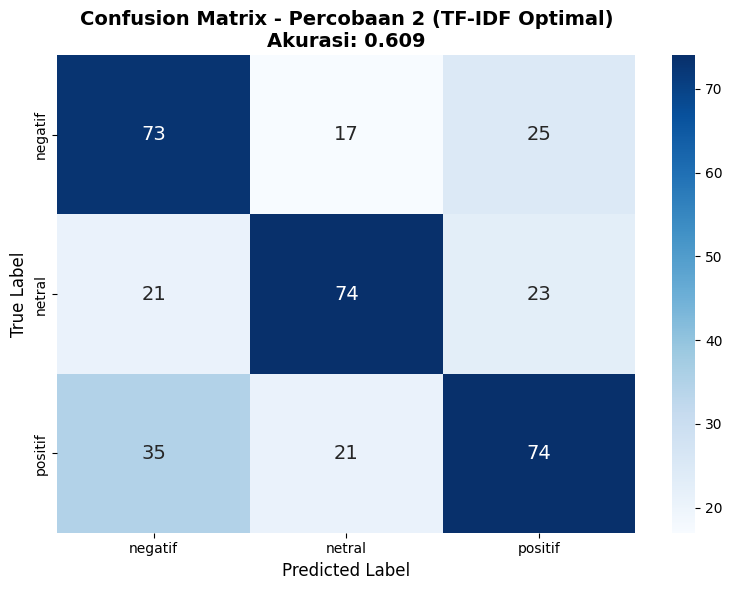

In [ ]:
# ============================================
# 5. EVALUASI
# ============================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print(" 📊 HASIL EVALUASI")
print("="*60)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Akurasi: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Classification Report
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n🔢 Confusion Matrix:")
print(cm)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            annot_kws={'size': 14})
plt.title(f'Confusion Matrix - Percobaan 2 (TF-IDF Optimal)\nAkurasi: {accuracy:.3f}',
          fontweight='bold', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('percobaan1_confusion_matrix.png', dpi=150)
plt.show()
